<a href="https://colab.research.google.com/github/Nisarga25/ML_2_063/blob/main/confmatrix(063).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IRIS FLOWER CLASSIFICATION DATASET

First 10 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa



Dataset Shape:
(150, 5)

Column Names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Features:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Target:
species

Training Samples: 120
Testing Samples : 30

Model trained successfully!

Actual Values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']

Predicted Values:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'vi

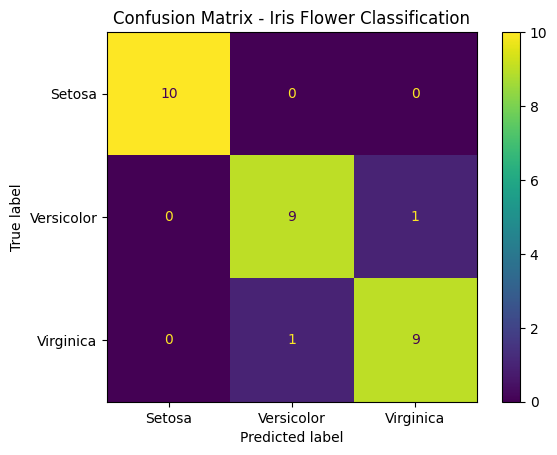

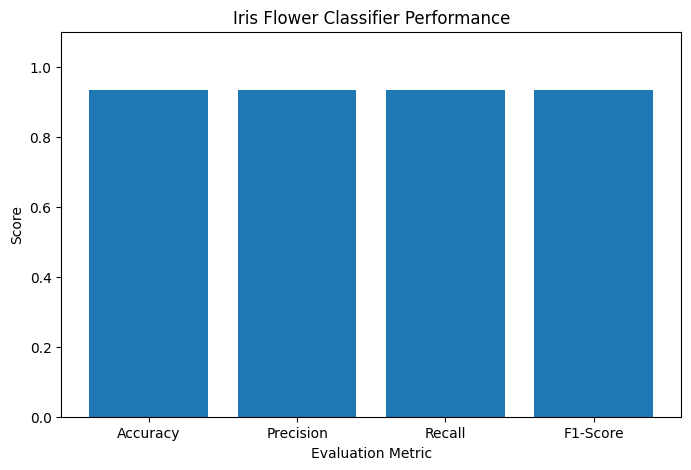

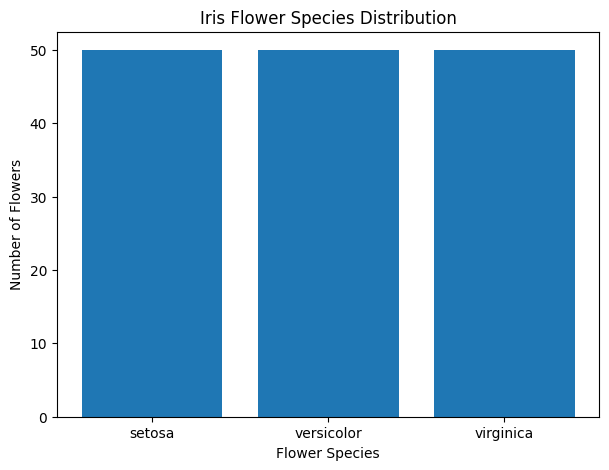

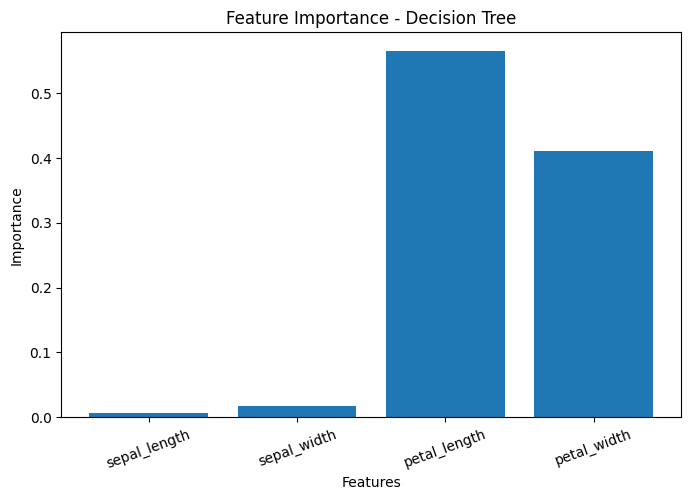


NEW FLOWER PREDICTION
Predicted Species: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
# ============================================================
# PROGRAM 2: BASIC SUPERVISED LEARNING PIPELINE
# Dataset: Iris Flower Classification
# Algorithm: Decision Tree Classifier
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

print("IRIS FLOWER CLASSIFICATION DATASET")
print("=" * 60)

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

df["species"] = iris.target


# Convert numeric labels into flower names

df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})


print("\nFirst 10 rows:")
display(df.head(10))


# ============================================================
# 2. DATASET INFORMATION
# ============================================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# 3. CHECK FOR MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

y = df["species"]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("species")


# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples :", len(X_test))


# ============================================================
# 6. CREATE DECISION TREE CLASSIFIER
# ============================================================

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)


# ============================================================
# 7. TRAIN THE MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nModel trained successfully!")


# ============================================================
# 8. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)


# ============================================================
# 9. CALCULATE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 10. DISPLAY PERFORMANCE
# ============================================================

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 12. PLOT CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Setosa",
        "Versicolor",
        "Virginica"
    ]
)

disp.plot()

plt.title("Confusion Matrix - Iris Flower Classification")

plt.show()


# ============================================================
# 13. GRAPH - PERFORMANCE METRICS
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8, 5))

plt.bar(
    metrics,
    values
)

plt.ylim(0, 1.1)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.title("Iris Flower Classifier Performance")

plt.show()


# ============================================================
# 14. GRAPH - SPECIES DISTRIBUTION
# ============================================================

species_count = df["species"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    species_count.index,
    species_count.values
)

plt.xlabel("Flower Species")
plt.ylabel("Number of Flowers")

plt.title("Iris Flower Species Distribution")

plt.show()


# ============================================================
# 15. FEATURE IMPORTANCE
# ============================================================

importance = model.feature_importances_

plt.figure(figsize=(8, 5))

plt.bar(
    X.columns,
    importance
)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance - Decision Tree")

plt.xticks(rotation=20)

plt.show()


# ============================================================
# 16. TEST WITH A NEW FLOWER
# ============================================================

new_flower = [[
    5.1,    # Sepal Length
    3.5,    # Sepal Width
    1.4,    # Petal Length
    0.2     # Petal Width
]]

prediction = model.predict(new_flower)

print("\n" + "=" * 60)
print("NEW FLOWER PREDICTION")
print("=" * 60)

print("Predicted Species:", prediction[0])
